In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from delta_hedge import simulate_gbm_path, delta_hedge_simulation
from scipy.stats import norm as _norm

plt.rcParams['figure.dpi'] = 100
sns.set_theme(style='whitegrid')

S0, K, T, r = 100.0, 100.0, 1.0, 0.05
sigma_impl   = 0.20
sigma_real   = 0.20
n_daily      = 252
seed         = 42

def fast_mc_pnl(S0, K, T, r, sigma_impl, sigma_real, n_steps, n_sims, seed=0):
    """Vectorized delta-hedge P&L over n_sims paths simultaneously.
    Pre-computes all paths + Greeks as (n_sims, n_steps) matrices.
    Loop runs n_steps times (not n_sims*n_steps), giving ~100x speedup.
    """
    dt = T / n_steps
    rng = np.random.default_rng(seed)
    Z = rng.standard_normal((n_sims, n_steps))
    log_ret = (r - 0.5*sigma_real**2)*dt + sigma_real*np.sqrt(dt)*Z
    S = np.empty((n_sims, n_steps + 1))
    S[:, 0] = S0
    S[:, 1:] = S0 * np.exp(np.cumsum(log_ret, axis=1))

    tau = np.maximum(T - np.arange(n_steps + 1)*dt, 0.0)
    Sc, Sn = S[:, :-1], S[:, 1:]
    tc, tn = tau[:-1], tau[1:]

    sqrt_tc = np.sqrt(np.maximum(tc, 1e-10))
    d1c = (np.log(Sc/K) + (r + 0.5*sigma_impl**2)*tc) / (sigma_impl*sqrt_tc)
    d2c = d1c - sigma_impl*sqrt_tc

    sqrt_tn = np.sqrt(np.maximum(tn, 1e-10))
    d1n = (np.log(Sn/K) + (r + 0.5*sigma_impl**2)*np.maximum(tn, 1e-10)) / (sigma_impl*sqrt_tn)
    d2n = d1n - sigma_impl*sqrt_tn

    Vc = Sc*_norm.cdf(d1c) - K*np.exp(-r*tc)*_norm.cdf(d2c)
    Vn = np.where(tn > 1e-10,
                  Sn*_norm.cdf(d1n) - K*np.exp(-r*tn)*_norm.cdf(d2n),
                  np.maximum(Sn - K, 0.0))
    dc = _norm.cdf(d1c)
    dn = np.where(tn > 1e-10, _norm.cdf(d1n),
                  np.where(Sn > K, 1.0, 0.0))

    stock_opt = (dc*(Sn - Sc) - (Vn - Vc)).sum(axis=1)

    cash = Vc[:, 0] - dc[:, 0]*Sc[:, 0]
    total_int = np.zeros(n_sims)
    for i in range(n_steps):
        total_int += r*cash*dt
        cash = cash*(1 + r*dt) - (dn[:, i] - dc[:, i])*Sn[:, i]

    return stock_opt + total_int


## 1. Une trajectoire delta-hedgée commentée

Vente d'un call ATM à 20 % de vol, couverture quotidienne (252 rebalancements).


In [2]:
df, pnl_total = delta_hedge_simulation(
    S0, K, T, r, sigma_impl, sigma_real, n_daily, seed
)
print(f'Prime encaissée à t=0 : {df["V"].iloc[0]:.4f}')
print(f'P&L total             : {pnl_total:+.4f}')
print(f'Spot final S_T        : {simulate_gbm_path(S0, T, r, sigma_real, n_daily, seed)[-1]:.4f}')


Prime encaissée à t=0 : 10.4506
P&L total             : +0.7111
Spot final S_T        : 88.3759


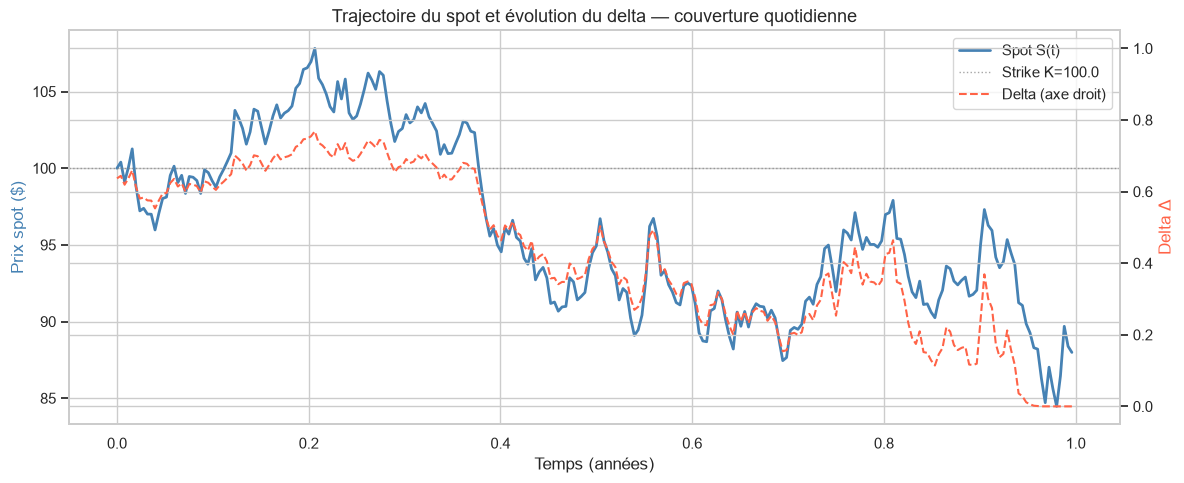

Saved: figures/15_delta_hedge_trajectory.png


In [3]:
fig, ax1 = plt.subplots(figsize=(12, 5))
ax2 = ax1.twinx()

ax1.plot(df['t'], df['S'], color='steelblue', lw=2, label='Spot S(t)')
ax1.axhline(K, color='grey', ls=':', lw=1, alpha=0.7, label=f'Strike K={K}')
ax2.plot(df['t'], df['delta'], color='tomato', lw=1.5, ls='--', label='Delta (axe droit)')

ax1.set_xlabel('Temps (années)')
ax1.set_ylabel('Prix spot ($)', color='steelblue')
ax2.set_ylabel('Delta Δ', color='tomato')
ax2.set_ylim(-0.05, 1.05)
ax1.set_title('Trajectoire du spot et évolution du delta — couverture quotidienne', fontsize=13)

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, loc='upper right')

plt.tight_layout()
plt.savefig('../figures/15_delta_hedge_trajectory.png', dpi=150)
plt.show()
print('Saved: figures/15_delta_hedge_trajectory.png')


### Interprétation : le rebalancement delta-neutre

À chaque pas de temps $dt$, le vendeur ajuste sa position en actions pour que le portefeuille reste **delta-neutre** :

$$\Delta_{t+dt} - \Delta_t = \Gamma \cdot dS$$

- Quand le spot **monte**, $\Delta$ augmente (call se rapproche de l'exercice) → il faut **acheter** des actions pour couvrir.
- Quand le spot **baisse**, $\Delta$ diminue → il faut **vendre** des actions.

Le coût de ce rebalancement continu est la **prime de Gamma** : le vendeur supporte le $\frac{1}{2}\Gamma(dS)^2$ à chaque pas, compensé (en espérance) par le **Theta** encaissé chaque jour.


## 2. Attribution du P&L — décomposition Taylor

Le P&L incrémental d'un call vendu delta-hedgé s'écrit :

$$\text{PnL}_{dt} \approx \underbrace{-\tfrac{1}{2}\Gamma (dS)^2}_{\text{coût gamma}} \underbrace{-\Theta_{\text{ann}} dt}_{\text{gain theta}} + \underbrace{r \cdot \text{cash} \cdot dt}_{\text{intérêts}}$$

In [4]:
gamma_cost = -df['gamma_term'].sum()        # négatif
theta_gain = -df['theta_term'].sum()        # positif (theta < 0 pour call long)
interest   =  df['interest'].sum()
residual   = pnl_total - (gamma_cost + theta_gain + interest)

components = {
    'Gain Theta': theta_gain,
    'Coût Gamma': gamma_cost,
    'Intérêts':   interest,
    'Résidu (Taylor)': residual,
}
total = pnl_total

print('Attribution P&L :')
for k, v in components.items():
    print(f'  {k:20s}: {v:+.4f}')
print(f'  {"─"*30}')
print(f'  {"P&L total":20s}: {total:+.4f}')


Attribution P&L :
  Gain Theta          : +6.7183
  Coût Gamma          : -4.1274
  Intérêts            : -1.8306
  Résidu (Taylor)     : -0.0493
  ──────────────────────────────
  P&L total           : +0.7111


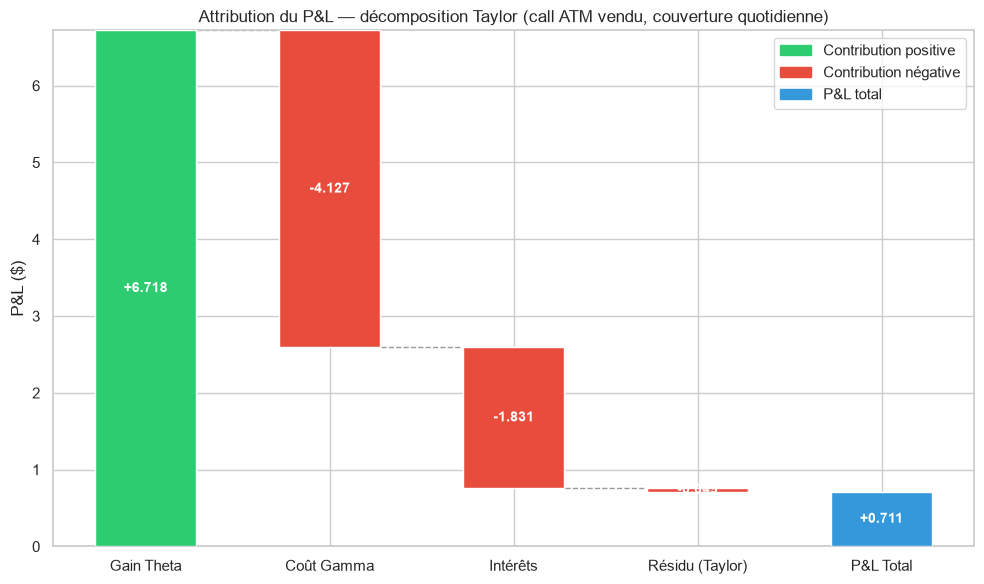

Saved: figures/16_pnl_attribution.png


In [5]:
labels = list(components.keys()) + ['P&L Total']
values = list(components.values())
colors_bar = ['#2ecc71' if v >= 0 else '#e74c3c' for v in values]

# Waterfall: running bottom
bottoms = []
cumul = 0.0
for v in values:
    bottoms.append(cumul)
    cumul += v

fig, ax = plt.subplots(figsize=(10, 6))

# Component bars (waterfall)
for i, (lbl, val, bot, col) in enumerate(zip(labels, values, bottoms, colors_bar)):
    ax.bar(i, val, bottom=bot, color=col, edgecolor='white', width=0.55, zorder=3)
    yc = bot + val / 2
    ax.text(i, yc, f'{val:+.3f}', ha='center', va='center',
            fontsize=10, fontweight='bold', color='white', zorder=4)

# Connector lines between bars
for i in range(len(values) - 1):
    y_conn = bottoms[i + 1]
    ax.hlines(y_conn, i + 0.28, i + 0.72, colors='#555', lw=1,
              linestyles='--', alpha=0.6, zorder=2)

# Total bar (from 0)
col_tot = '#2ecc71' if total >= 0 else '#e74c3c'
ax.bar(len(labels) - 1, total, bottom=0, color='#3498db',
       edgecolor='white', width=0.55, zorder=3)
ax.text(len(labels) - 1, total / 2, f'{total:+.3f}', ha='center',
        va='center', fontsize=10, fontweight='bold', color='white', zorder=4)

ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, fontsize=11)
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('P&L ($)')
ax.set_title('Attribution du P&L — décomposition Taylor (call ATM vendu, couverture quotidienne)',
             fontsize=12)

legend_patches = [
    mpatches.Patch(color='#2ecc71', label='Contribution positive'),
    mpatches.Patch(color='#e74c3c', label='Contribution négative'),
    mpatches.Patch(color='#3498db', label='P&L total'),
]
ax.legend(handles=legend_patches, loc='upper right')
plt.tight_layout()
plt.savefig('../figures/16_pnl_attribution.png', dpi=150)
plt.show()
print('Saved: figures/16_pnl_attribution.png')


### Interprétation : short Gamma, long Theta

Le vendeur d'option delta-hedgé est dans une position fondamentale :

| Position | Gain | Risque |
|---|---|---|
| **Short Gamma** | — | Perd $\frac{1}{2}\Gamma(dS)^2$ à chaque grand mouvement |
| **Long Theta** | Encaisse $|\Theta|$ par jour | — |

En espérance (lorsque $\sigma_{\text{réal}} = \sigma_{\text{impl}}$), ces deux termes se compensent exactement, grâce à l'équation de Black-Scholes :

$$\Theta_{\text{ann}} + \frac{1}{2}\sigma^2 S^2 \Gamma + r S \Delta = r V$$

Sur un chemin particulier, le P&L dépend de la volatilité réalisée par rapport à la volatilité implicite.


## 3. Couverture quotidienne vs hebdomadaire — erreur de réplication

Plus la fréquence de rebalancement est élevée, plus l'erreur de couverture est réduite.
Théoriquement, l'écart-type du P&L scale comme $\sqrt{T/n}$ (où $n$ = nombre de pas).


In [6]:
n_sims   = 1000
n_weekly = 52

pnl_daily  = np.array([delta_hedge_simulation(S0, K, T, r, sigma_impl, sigma_real,
                                               n_daily,  seed=s)[1] for s in range(n_sims)])
pnl_weekly = np.array([delta_hedge_simulation(S0, K, T, r, sigma_impl, sigma_real,
                                               n_weekly, seed=s)[1] for s in range(n_sims)])

std_d = np.std(pnl_daily)
std_w = np.std(pnl_weekly)
ratio_empirique = std_w / std_d
ratio_theorique = np.sqrt(n_daily / n_weekly)

print(f'Quotidien (n={n_daily:3d}) — moyenne: {np.mean(pnl_daily):+.4f}   std: {std_d:.4f}')
print(f'Hebdo     (n={n_weekly:3d}) — moyenne: {np.mean(pnl_weekly):+.4f}   std: {std_w:.4f}')
print()
print(f'Ratio std_hebdo / std_quotidien  = {ratio_empirique:.3f}')
print(f'Valeur théorique sqrt({n_daily}/{n_weekly}) = {ratio_theorique:.3f}')


Quotidien (n=252) — moyenne: -0.0041   std: 0.4391
Hebdo     (n= 52) — moyenne: +0.0540   std: 0.9465

Ratio std_hebdo / std_quotidien  = 2.156
Valeur théorique sqrt(252/52) = 2.201


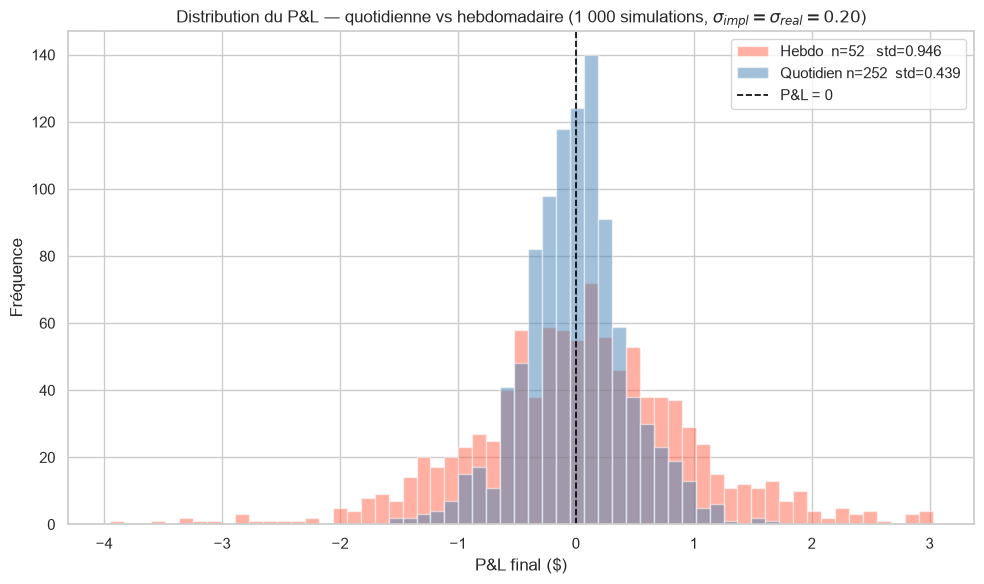

Saved: figures/17_hedge_frequency.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

bins = np.linspace(min(pnl_weekly.min(), pnl_daily.min()),
                   max(pnl_weekly.max(), pnl_daily.max()), 60)

ax.hist(pnl_weekly, bins=bins, alpha=0.5, color='tomato',
        label=f'Hebdo  n=52   std={std_w:.3f}')
ax.hist(pnl_daily,  bins=bins, alpha=0.5, color='steelblue',
        label=f'Quotidien n=252  std={std_d:.3f}')
ax.axvline(0, color='black', lw=1.2, ls='--', label='P&L = 0')

ax.set_xlabel('P&L final ($)')
ax.set_ylabel('Fréquence')
ax.set_title('Distribution du P&L — quotidienne vs hebdomadaire'
             f' (1 000 simulations, $\sigma_{{impl}}=\sigma_{{real}}=0.20$)',
             fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../figures/17_hedge_frequency.png', dpi=150)
plt.show()
print('Saved: figures/17_hedge_frequency.png')


### Interprétation : fréquence de rebalancement

- La couverture **quotidienne** (n=252) produit une distribution **plus resserrée** que l'hebdomadaire (n=52).
- L'écart-type scale empiriquement comme $\sqrt{T/n}$, conformément à la théorie du hedging discret (Leland 1985, Wilmott 1998).
- En pratique, augmenter la fréquence réduit l'erreur de couverture mais **augmente les coûts de transaction** (bid-ask spread, impact de marché). L'optimum dépend de la taille de $\Gamma$ et des coûts.


## 4. P&L du vendeur en fonction de $\sigma_{\text{réal}}$ ($\sigma_{\text{impl}} = 0.20$ fixé)

Lorsque $\sigma_{\text{réal}} \neq \sigma_{\text{impl}}$, l'espérance du P&L du delta-hedge est :

$$\mathbb{E}[\text{PnL}] \approx -\frac{1}{2} \int_0^T \Gamma_t S_t^2 \bigl(\sigma_{\text{réal}}^2 - \sigma_{\text{impl}}^2\bigr) dt$$

- $\sigma_{\text{réal}} < \sigma_{\text{impl}}$ : le vendeur a **surpayé** la vol implicite → il gagne.
- $\sigma_{\text{réal}} > \sigma_{\text{impl}}$ : la vol réalisée dépasse l'implicite → il perd.

In [8]:
sigma_reals = np.linspace(0.10, 0.30, 11)
n_sims_vol  = 500   # paths per vol level (fast_mc_pnl runs all at once)

mean_pnls = []
std_pnls  = []

for sig_r in sigma_reals:
    pnls = fast_mc_pnl(S0, K, T, r, sigma_impl, sig_r, n_daily, n_sims_vol, seed=0)
    mean_pnls.append(pnls.mean())
    std_pnls.append(pnls.std())

mean_pnls = np.array(mean_pnls)
std_pnls  = np.array(std_pnls)

for sr, mp, sp in zip(sigma_reals, mean_pnls, std_pnls):
    print(f'sigma_real={sr:.2f}  P&L moyen={mp:+.4f}   std={sp:.4f}')


sigma_real=0.10  P&L moyen=+3.8071   std=1.1327
sigma_real=0.12  P&L moyen=+3.0560   std=0.9930
sigma_real=0.14  P&L moyen=+2.2939   std=0.8228
sigma_real=0.16  P&L moyen=+1.5297   std=0.6417
sigma_real=0.18  P&L moyen=+0.7619   std=0.4740
sigma_real=0.20  P&L moyen=-0.0073   std=0.4183
sigma_real=0.22  P&L moyen=-0.7723   std=0.5539
sigma_real=0.24  P&L moyen=-1.5338   std=0.8083
sigma_real=0.26  P&L moyen=-2.2947   std=1.1232
sigma_real=0.28  P&L moyen=-3.0586   std=1.4757
sigma_real=0.30  P&L moyen=-3.8243   std=1.8588


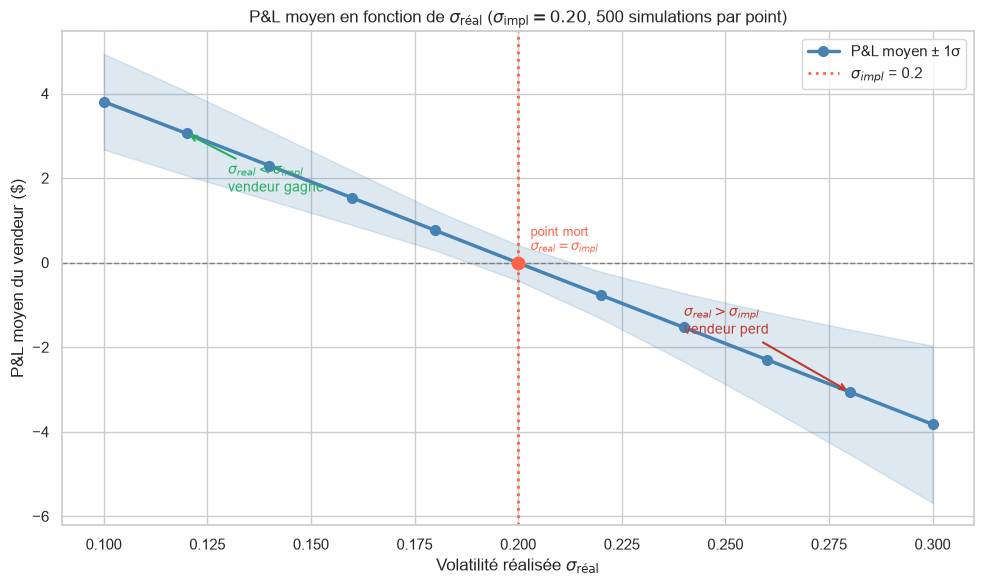

Saved: figures/18_vol_mismatch_pnl.png


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.fill_between(sigma_reals, mean_pnls - std_pnls, mean_pnls + std_pnls,
                alpha=0.18, color='steelblue')
ax.plot(sigma_reals, mean_pnls, 'o-', color='steelblue', lw=2.5, ms=7,
        label='P&L moyen ± 1σ')
ax.axhline(0, color='grey', lw=1, ls='--')
ax.axvline(sigma_impl, color='tomato', lw=2, ls=':', label=f'$\sigma_{{impl}}$ = {sigma_impl}')

# Annotations
idx_gain = 1   # sigma_real = 0.12
idx_loss = 9   # sigma_real = 0.28
ax.annotate('$\sigma_{{real}} < \sigma_{{impl}}$\nvendeur gagne',
            xy=(sigma_reals[idx_gain], mean_pnls[idx_gain]),
            xytext=(sigma_reals[idx_gain] + 0.01, mean_pnls[idx_gain] * 0.55),
            arrowprops=dict(arrowstyle='->', color='#27ae60', lw=1.5),
            color='#27ae60', fontsize=10)
ax.annotate('$\sigma_{{real}} > \sigma_{{impl}}$\nvendeur perd',
            xy=(sigma_reals[idx_loss], mean_pnls[idx_loss]),
            xytext=(sigma_reals[idx_loss] - 0.04, mean_pnls[idx_loss] * 0.55),
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=1.5),
            color='#c0392b', fontsize=10)

# Point mort
ax.scatter([sigma_impl], [0], color='tomato', s=80, zorder=5)
ax.text(sigma_impl + 0.003, 0.3, 'point mort\n$\sigma_{{real}}=\sigma_{{impl}}$',
        fontsize=9, color='tomato')

ax.set_xlabel('Volatilité réalisée $\sigma_{\mathrm{réal}}$', fontsize=12)
ax.set_ylabel('P&L moyen du vendeur ($)', fontsize=12)
ax.set_title('P&L moyen en fonction de $\sigma_{\mathrm{réal}}$ '
             '($\sigma_{\mathrm{impl}}=0.20$, 500 simulations par point)', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('../figures/18_vol_mismatch_pnl.png', dpi=150)
plt.show()
print('Saved: figures/18_vol_mismatch_pnl.png')


### Interprétation : le vrai moteur de P&L du vendeur

La courbe ci-dessus illustre un principe fondamental de la **vente de volatilité** :

| Scénario | Résultat |
|---|---|
| $\sigma_{\text{réal}} \ll \sigma_{\text{impl}}$ | Gain important : le marché a peu bougé, le theta encaissé dépasse le coût gamma |
| $\sigma_{\text{réal}} = \sigma_{\text{impl}}$ | P&L ≈ 0 en espérance (Black-Scholes est *fair*) |
| $\sigma_{\text{réal}} \gg \sigma_{\text{impl}}$ | Perte : les mouvements du marché coûtent plus que le theta collecté |

**Conclusion** : le vendeur d'option est fondamentalement un **vendeur de variance**.
Son P&L est piloté par l'écart entre la variance réalisée $\sigma_{\text{réal}}^2$ et la variance implicite $\sigma_{\text{impl}}^2$, pondéré par le gamma du portefeuille.
C'est la base de l'arbitrage de variance et des stratégies de trading de volatilité.
